In [21]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import random
from sklearn.decomposition import PCA

# Import our utility functions
from ex_week_10_utils import (load_mnist_data, plot_data_list, plot_embeddings_2d, 
                               plot_embeddings_comparison, plot_reconstructions,
                               load_model_if_valid, save_model)

# Set random seeds for reproducibility
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Check if GPU is available
device = torch.device("mps" if torch.mps.is_available() else "cpu")
print(f"Using device: {device}")


Using device: mps


In [22]:
# Load MNIST data using our utility function
train_loader, val_loader, test_loader = load_mnist_data(batch_size=128, validation_split=0.1)

print("Data loaded successfully!")
print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Data loaded successfully!
Train batches: 422
Validation batches: 47
Test batches: 79


In [23]:
class CNNAutoencoder(nn.Module):
    """
    CNN Autoencoder for MNIST images.
    Compresses 28×28 images into a low-dimensional latent space and reconstructs them.
    """
    def __init__(self, latent_dim=32):
        super(CNNAutoencoder, self).__init__()
        self.latent_dim = latent_dim
        
        # Encoder: CNN layers
        self.encoder = nn.Sequential(
            # Input: (batch, 1, 28, 28) #This tells us that there is only 1 color channel in the mnist images
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),  # 28x28 -> 28x28
            nn.ReLU(),
            nn.BatchNorm2d(16),
            nn.MaxPool2d(2, 2),  # 28x28 -> 14x14
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),  # 14x14 -> 14x14
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2, 2),  # 14x14 -> 7x7
            nn.Flatten(),
            # Add intermediate layer
            nn.Linear(32 * 7 * 7, 128), # Think about why it is 32 * 7 * 7 (hint: How many kernels are there in the last conv layer?)
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, latent_dim),
            nn.BatchNorm1d(latent_dim)
        )
        
        # Decoder: Transpose CNN layers
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, 32 * 7 * 7), # Hint: We are basically constructing the inverse of the encoder
            nn.ReLU(),
            nn.BatchNorm1d(32 * 7 * 7),
            nn.Unflatten(1, (32, 7, 7)),
            # Upsample: 7x7 -> 14x14
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(16),
            # Upsample: 14x14 -> 28x28
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()  # Output in [0, 1] range
        )
    
    def encode(self, x):
        """Extract embeddings from input images."""
        return self.encoder(x)
    
    def decode(self, z):
        """Reconstruct images from embeddings."""
        return self.decoder(z)
    
    def forward(self, x):
        """Forward pass: encode then decode."""
        # TODO: First encode the input, then decode the latent representation
        latent_embedding = self.encode(x)
        x_recon = self.decode(latent_embedding)
        return x_recon


In [24]:
def train_epoch(model, loader, optimizer, criterion, device):
    """Train autoencoder for one epoch"""
    model.train()
    total_loss = 0.0
    
    for images, labels in loader:
        images = images.to(device)
        
        # TODO: Forward pass - get reconstruction from model
        reconstructions = model(images)
        
        # TODO: Compute loss between reconstructions and original images
        loss = criterion(reconstructions, images)
        
        # TODO: Backward pass - zero gradients, backward, and update weights. You have worked with this before, look through old exercises and assignments if you are in doubt
        # You will write these 3 lines a billion times in your lives as AI engineers, so better get used to them now ;)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Track metrics
        total_loss += loss.item()
    
    avg_loss = total_loss / len(loader)
    return avg_loss

def evaluate(model, loader, criterion, device):
    """Evaluate autoencoder on a dataset"""
    model.eval()
    total_loss = 0.0
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            
            # TODO: Forward pass - get reconstruction from model
            reconstructions = model(images)
            
            # TODO: Compute loss between reconstructions and original images
            loss = criterion(reconstructions, images)
            
            # Track metrics
            total_loss += loss.item()
    
    avg_loss = total_loss / len(loader)
    return avg_loss

def train_model(model, train_loader, val_loader, num_epochs, lr, device):
    """Complete training loop for autoencoder"""
    model = model.to(device)
    criterion = nn.MSELoss()  # Reconstruction loss
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    
    for epoch in range(num_epochs):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss = evaluate(model, val_loader, criterion, device)
        
        print(f"Epoch {epoch+1}/{num_epochs}:")
        print(f"  Train Loss: {train_loss:.6f}")
        print(f"  Val Loss: {val_loss:.6f}")
    
    return model

In [25]:
# Hyperparameters
latent_dim = 64  # Latent space dimension
num_epochs = 5   # Number of training epochs
learning_rate = 0.001

# Model save paths (saved in models/ directory)
model1_path = 'models/model1_ae.pth'
model2_path = 'models/model2_ae.pth'

# Train or load Autoencoder 1 with seed 42
print("="*60)
print("Autoencoder 1 (seed=42)")
print("="*60)
set_seed(42)
model1, loaded = load_model_if_valid(model1_path, CNNAutoencoder, device, latent_dim=latent_dim)
if not loaded:
    print("Training Autoencoder 1...")
    model1 = CNNAutoencoder(latent_dim=latent_dim)
    model1 = train_model(model1, train_loader, val_loader, num_epochs, learning_rate, device)
    save_model(model1, model1_path, CNNAutoencoder, latent_dim=latent_dim)

# Train or load Autoencoder 2 with seed 123
print("\n" + "="*60)
print("Autoencoder 2 (seed=123)")
print("="*60)
set_seed(123)
model2, loaded = load_model_if_valid(model2_path, CNNAutoencoder, device, latent_dim=latent_dim)
if not loaded:
    print("Training Autoencoder 2...")
    model2 = CNNAutoencoder(latent_dim=latent_dim)
    model2 = train_model(model2, train_loader, val_loader, num_epochs, learning_rate, device)
    save_model(model2, model2_path, CNNAutoencoder, latent_dim=latent_dim)

print("\n" + "="*60)
print("Both autoencoders ready!")
print("="*60)


Autoencoder 1 (seed=42)
Loaded pre-trained model from models/model1_ae.pth

Autoencoder 2 (seed=123)
Loaded pre-trained model from models/model2_ae.pth

Both autoencoders ready!


Reconstruction Examples from Both Autoencoders
Saved visualization to 'autoencoder_reconstructions.png'


/Users/aslandalhoffbehbahani/Bachelor/VSBachelor/src/lora/ex_week_10_utils.py:425: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.97 if suptitle else 1])


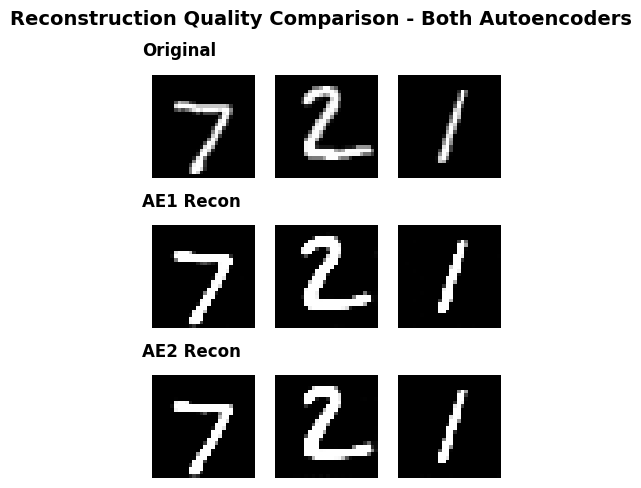

In [26]:
# Show reconstruction examples from both trained autoencoders
print("="*60)
print("Reconstruction Examples from Both Autoencoders")
print("="*60)

# Get a small batch of test images for visualization
test_images_batch, test_labels_batch = next(iter(test_loader))
num_examples = 3
test_images_vis = test_images_batch[:num_examples].to(device)

# Unnormalize images for proper visualization (reverse the normalization)
test_images_unnorm = test_images_vis * 0.3081 + 0.1307
test_images_unnorm = torch.clamp(test_images_unnorm, 0, 1)

# Get reconstructions from both models

#TODO: Put both models into eval mode. This has been done before in previous exercises and assignments
model1.eval()
model2.eval()
with torch.no_grad():
    #TODO: Get reconstructions from each model
    recon1 = model1(test_images_vis)
    recon2 = model2(test_images_vis)

# Plot reconstructions using the utility function
plot_reconstructions(
    images_list=[test_images_unnorm.cpu(), recon1.cpu(), recon2.cpu()],
    row_labels=['Original', 'AE1 Recon', 'AE2 Recon'],
    num_samples=num_examples,
    suptitle='Reconstruction Quality Comparison - Both Autoencoders',
    save_path='autoencoder_reconstructions.png'
)
plt.show()


In [27]:
def extract_embeddings(model, loader, device):
    """Extract embeddings and labels from a dataset"""
    model.eval()
    embeddings_list = []
    labels_list = []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            
            # Get embeddings (encoder only, no classifier)
            emb = model.encode(images)
            
            embeddings_list.append(emb.cpu())
            labels_list.append(labels)
    
    # Concatenate all batches
    embeddings = torch.cat(embeddings_list, dim=0).numpy()
    labels = torch.cat(labels_list, dim=0).numpy()
    
    return embeddings, labels

# Extract embeddings from both models on the test set
print("Extracting embeddings from Model 1...")
embeddings1, labels1 = extract_embeddings(model1, test_loader, device)

print("Extracting embeddings from Model 2...")
embeddings2, labels2 = extract_embeddings(model2, test_loader, device)

print(f"\nModel 1 embeddings shape: {embeddings1.shape}")
print(f"Model 2 embeddings shape: {embeddings2.shape}")
print(f"Labels shape: {labels1.shape}")

# Verify labels are the same (they should be, since we use the same test set)
assert np.array_equal(labels1, labels2), "Labels should be identical!"
labels = labels1  # Use either one


Extracting embeddings from Model 1...
Extracting embeddings from Model 2...

Model 1 embeddings shape: (10000, 64)
Model 2 embeddings shape: (10000, 64)
Labels shape: (10000,)


In [28]:
# Apply PCA to project 64D embeddings to 2D for visualization

from sklearn.decomposition import PCA

# Model 1: Fit PCA and transform
pca1 = PCA(n_components=2)
embeddings1_2d = pca1.fit_transform(embeddings1)

# Model 2: Fit separate PCA and transform (different embedding space!)
pca2 = PCA(n_components=2)
embeddings2_2d = pca2.fit_transform(embeddings2)


/Users/aslandalhoffbehbahani/Bachelor/VSBachelor/src/lora/ex_week_10_utils.py:309: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=(0, 1.0, 0.95, 1))


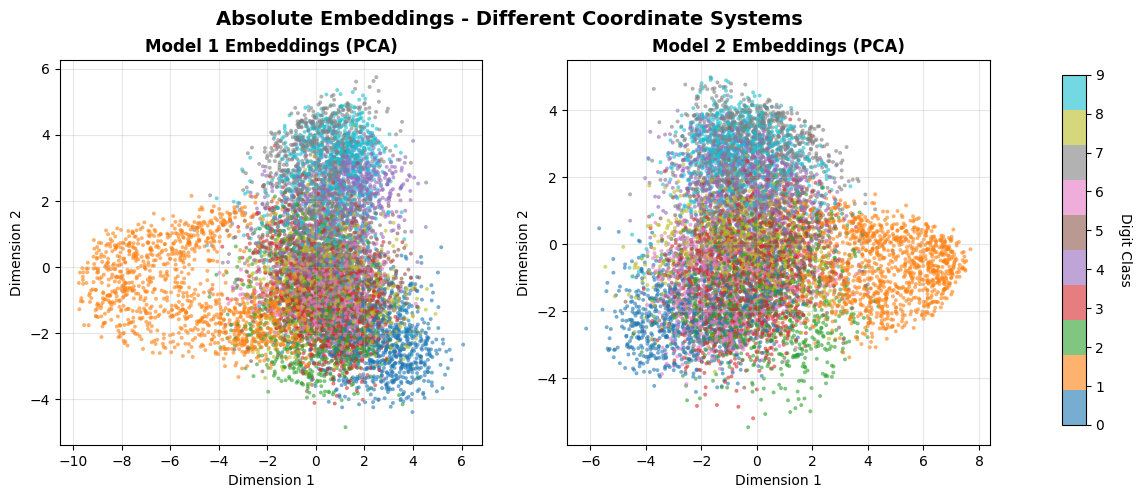

In [29]:


# Plot the 2D projections side by side
fig, axes = plot_embeddings_comparison(
    embeddings1_2d, embeddings2_2d, labels,
    title1='Model 1 Embeddings (PCA)', 
    title2='Model 2 Embeddings (PCA)',
    suptitle='Absolute Embeddings - Different Coordinate Systems'
)
plt.show()


Saved visualization to 'failed_stitching_comparison.png'


/Users/aslandalhoffbehbahani/Bachelor/VSBachelor/src/lora/ex_week_10_utils.py:425: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.97 if suptitle else 1])


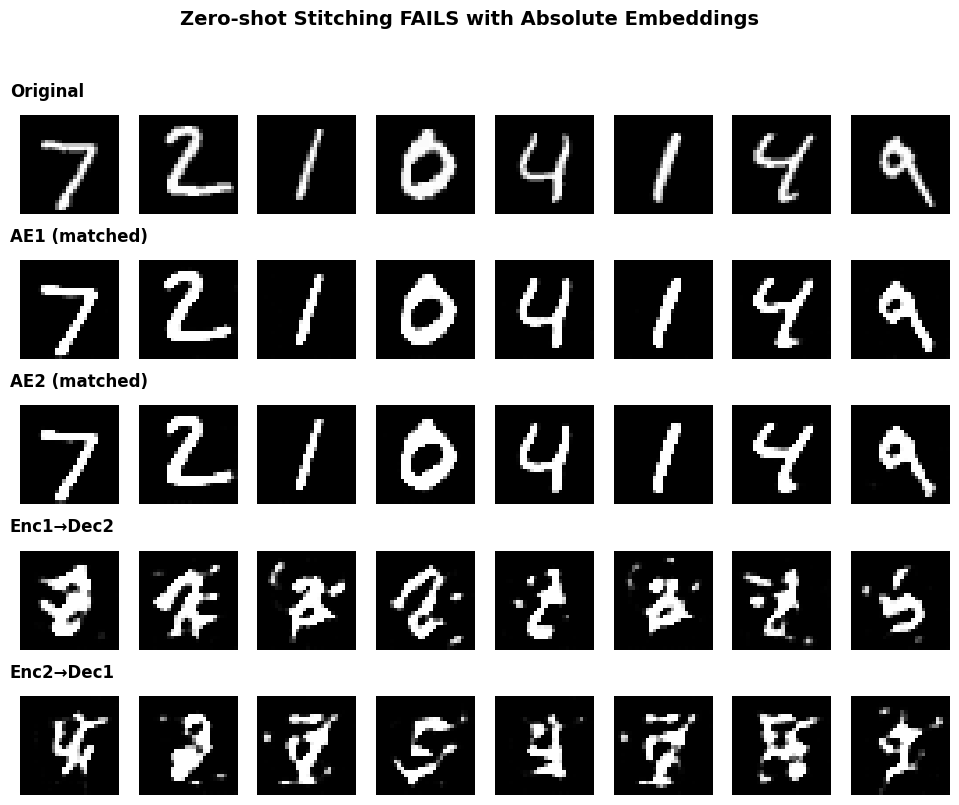

In [30]:
model1.eval()
model2.eval()

# Take 8 test images for visualization (unnormalized for plotting)
vis_images, _ = next(iter(test_loader))
vis_images = vis_images[:8].to(device)
vis_images_unnorm = vis_images * 0.3081 + 0.1307

with torch.no_grad():
    vis_recon1 = model1(vis_images)
    vis_recon2 = model2(vis_images)
    
    # Mismatched reconstructions
    vis_emb1 = model1.encode(vis_images)
    vis_recon1_to_2 = model2.decode(vis_emb1)
    
    vis_emb2 = model2.encode(vis_images)
    vis_recon2_to_1 = model1.decode(vis_emb2)

# Use utility function to plot
plot_reconstructions(
    images_list=[vis_images_unnorm, vis_recon1, vis_recon2, vis_recon1_to_2, vis_recon2_to_1],
    row_labels=['Original', 'AE1 (matched)', 'AE2 (matched)', 'Enc1→Dec2', 'Enc2→Dec1'],
    num_samples=8,
    suptitle='Zero-shot Stitching FAILS with Absolute Embeddings',
    save_path='failed_stitching_comparison.png'
)
plt.show()

In [31]:
# Number of anchors - can be different from latent dimension!
num_anchors = 30 # TODO: Play around with this number if you like!

# Randomly select anchor indices
np.random.seed(42)  # For reproducibility
anchor_indices = np.random.choice(len(embeddings1), size=num_anchors, replace=False)

# Extract anchor embeddings from both autoencoders
# TODO: IMPORTANT: Use the same indices for both models such that the anchors are PARALLEL!
anchors1 = embeddings1[anchor_indices]
anchors2 = embeddings2[anchor_indices]

In [32]:
def compute_relative_representations(embeddings, anchors):
    """
    Compute relative representations using cosine similarity.
    
    Args:
        embeddings: numpy array of shape (n_samples, embedding_dim)
        anchors: numpy array of shape (n_anchors, embedding_dim)
    
    Returns:
        relrep: numpy array of shape (n_samples, n_anchors)
    """
    n_samples = embeddings.shape[0]
    n_anchors = anchors.shape[0]
    
    # Initialize relative representation matrix
    relrep = np.zeros((n_samples, n_anchors))
    
    # Compute cosine similarity for each (data point, anchor) pair
    for i in range(n_samples):
        x = embeddings[i]  # Current data point
        # TODO: Compute the norm (magnitude) of x using np.linalg.norm
        norm_x = np.linalg.norm(x)  # ||x||
        
        for j in range(n_anchors):
            a = anchors[j]  # Current anchor
            # TODO: Compute the norm (magnitude) of a
            norm_a = np.linalg.norm(a)  # ||a||
            
            # TODO: Compute cosine similarity (defined earlier)
            # Use np.dot for the dot product, add 1e-8 to denominator to avoid division by zero
            dot_product = np.dot(x, a)
            cosine_sim = dot_product / (norm_x * norm_a + 1e-8)
            
            relrep[i, j] = cosine_sim
    
    return relrep

# Compute relative representations for both models
relrep1 = compute_relative_representations(embeddings1, anchors1)
relrep2 = compute_relative_representations(embeddings2, anchors2)

print(f"Original embedding dimension: {latent_dim}")
print(f"Relative representation dimension: {num_anchors}")
print("Relative representations shape:", relrep1.shape)


Original embedding dimension: 64
Relative representation dimension: 30
Relative representations shape: (10000, 30)


Plotting relative representations...


/Users/aslandalhoffbehbahani/Bachelor/VSBachelor/src/lora/ex_week_10_utils.py:309: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=(0, 1.0, 0.95, 1))


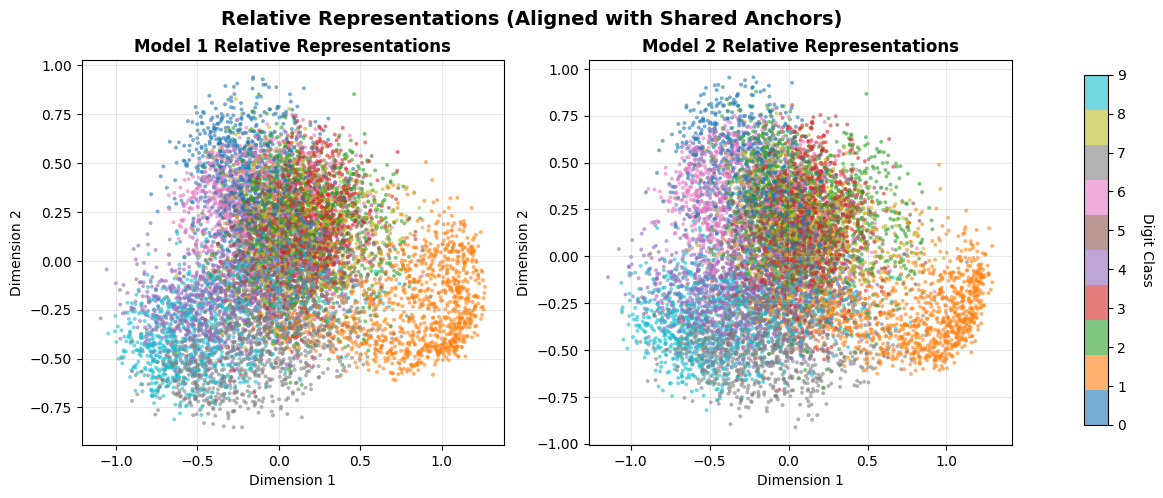

In [33]:
# Plot relative representations
print("Plotting relative representations...")

# # Apply PCA to reduce dimensions for visualization (shared PCA for both)
# pca_relrep = PCA(n_components=2)
# relrep1_2d = pca_relrep.fit_transform(relrep1)
# relrep2_2d = pca_relrep.transform(relrep2)  # Use same PCA transformation

concat_relrep = np.concatenate([relrep1, relrep2], axis=0)
pca_relrep = PCA(n_components=2).fit_transform(concat_relrep)
relrep1_2d = pca_relrep[:len(relrep1)]
relrep2_2d = pca_relrep[len(relrep1):]


# Plot using our utility function
fig, axes = plot_embeddings_comparison(
    relrep1_2d, relrep2_2d, labels,
    title1='Model 1 Relative Representations',
    title2='Model 2 Relative Representations',
    suptitle='Relative Representations (Aligned with Shared Anchors)'
)
plt.show()


In [34]:
# perform mrr evaluation on the relative representations
print("Evaluating MRR on relative representations...")
def compute_mrr(recon1, recon2):
    """
    Mean Reciprocal Rank: for each point i in recon1, rank all points in recon2
    by distance and record the rank of point i (the true match).
    MRR = mean(1 / rank). Perfect alignment → MRR = 1.0.
    """
    n = len(recon1)

    # Pairwise squared distances: (n, n)
    # ||a - b||^2 = ||a||^2 + ||b||^2 - 2 a·b
    r1_sq = np.sum(recon1 ** 2, axis=1, keepdims=True)   # (n, 1)
    r2_sq = np.sum(recon2 ** 2, axis=1, keepdims=True)   # (n, 1)
    dists = r1_sq + r2_sq.T - 2 * (recon1 @ recon2.T)    # (n, n)

    # For each row i, rank of column i (the true match) — argsort gives ascending order
    ranks = (np.argsort(dists, axis=1) == np.arange(n)[:, None]).argmax(axis=1) + 1  # 1-indexed

    mrr = float(np.mean(1.0 / ranks))

    print(f"=== Mean Reciprocal Rank ===")
    print(f"MRR:              {mrr:.4f}  (perfect = 1.0000, random ≈ {1/n:.6f})")
    print(f"Median rank:      {int(np.median(ranks))} / {n}")
    print(f"Rank 1 hits:      {np.sum(ranks == 1)} / {n}  ({np.mean(ranks == 1)*100:.2f}%)")
    print(f"Rank ≤ 10 hits:   {np.sum(ranks <= 10)} / {n}  ({np.mean(ranks <= 10)*100:.2f}%)")

    return mrr, ranks


mrr_after, ranks_after = compute_mrr(relrep1, relrep2)


Evaluating MRR on relative representations...
=== Mean Reciprocal Rank ===
MRR:              0.8596  (perfect = 1.0000, random ≈ 0.000100)
Median rank:      1 / 10000
Rank 1 hits:      8083 / 10000  (80.83%)
Rank ≤ 10 hits:   9463 / 10000  (94.63%)


In [35]:
# Similar structure to the autoencoder's decoder, but takes relrep as input

class RelativeDecoder(nn.Module):
    """
    Decoder that takes relative representations as input and reconstructs images.
    """
    def __init__(self, input_dim):
        super(RelativeDecoder, self).__init__()
        
        # Decode directly from relative representations to images
        self.decoder = nn.Sequential(
            # Map from relrep dimension to intermediate size
            # TODO: This is just a new decoder. You can just straight up copy the decoder architecture in here and change the input var
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, 32 * 7 * 7), # Hint: We are basically constructing the inverse of the encoder
            nn.ReLU(),
            nn.BatchNorm1d(32 * 7 * 7),
            nn.Unflatten(1, (32, 7, 7)),
            # Upsample: 7x7 -> 14x14
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(16),
            # Upsample: 14x14 -> 28x28
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()  # Output in [0, 1] range
        )
    
    def forward(self, relrep):
        """Forward pass: decode from relrep to image."""
        return self.decoder(relrep)


# Get original images for training the decoder
# We need to pair relreps with their corresponding images
print("Preparing datasets for RelativeDecoder training...")

# Convert numpy arrays to tensors
relrep1_tensor = torch.FloatTensor(relrep1)
relrep2_tensor = torch.FloatTensor(relrep2)

# Get images from test set (need to unnormalize and reshape properly)
images_list = []
for images, labels_batch in test_loader:
    images_list.append(images)
images_all = torch.cat(images_list, dim=0)

# Unnormalize images (reverse the normalization: x * std + mean)
images_all = images_all * 0.3081 + 0.1307
images_all = torch.clamp(images_all, 0, 1)  # Ensure in [0, 1] range

# Create datasets: (relrep, image) pairs
relrep1_dataset = TensorDataset(relrep1_tensor, images_all)
relrep2_dataset = TensorDataset(relrep2_tensor, images_all)

relrep1_loader = DataLoader(relrep1_dataset, batch_size=128, shuffle=True)
relrep2_loader = DataLoader(relrep2_dataset, batch_size=128, shuffle=False)

Preparing datasets for RelativeDecoder training...


In [36]:
# Train the RelativeDecoder on Autoencoder 1's relative representations
print("="*60)
print("RelativeDecoder on Autoencoder 1's relreps")
print("="*60)

# Initialize the RelativeDecoder
rel_decoder = RelativeDecoder(input_dim=num_anchors) # TODO: What is the dim of the relative space equal to?
rel_decoder = rel_decoder.to(device)

num_epochs_rel = 25
optimizer = torch.optim.Adam(rel_decoder.parameters(), lr=0.001, weight_decay=1e-5)
criterion = nn.MSELoss()  # Reconstruction loss

for epoch in range(num_epochs_rel):
    rel_decoder.train()
    train_loss = 0.0
    
    for relreps, images_batch in relrep1_loader:
        relreps = relreps.to(device) 
        images_batch = images_batch.to(device)
        
        # Forward pass: decode relreps to images
        reconstructions = rel_decoder(relreps)
        loss = criterion(reconstructions, images_batch)
        
        # TODO: Backward pass - zero gradients, backward, and update weights.
        # Here are the 3 lines again!
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Track metrics
        train_loss += loss.item()
    
    avg_loss = train_loss / len(relrep1_loader)
    if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == num_epochs_rel - 1:
        print(f"Epoch {epoch+1}/{num_epochs_rel}: Loss = {avg_loss:.6f}")

print("\n✓ RelativeDecoder training complete!")


RelativeDecoder on Autoencoder 1's relreps
Epoch 1/25: Loss = 0.193906
Epoch 5/25: Loss = 0.020596
Epoch 10/25: Loss = 0.012903
Epoch 15/25: Loss = 0.010771
Epoch 20/25: Loss = 0.009994
Epoch 25/25: Loss = 0.009628

✓ RelativeDecoder training complete!


Saved visualization to 'reconstruction_comparison.png'


/Users/aslandalhoffbehbahani/Bachelor/VSBachelor/src/lora/ex_week_10_utils.py:425: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.97 if suptitle else 1])


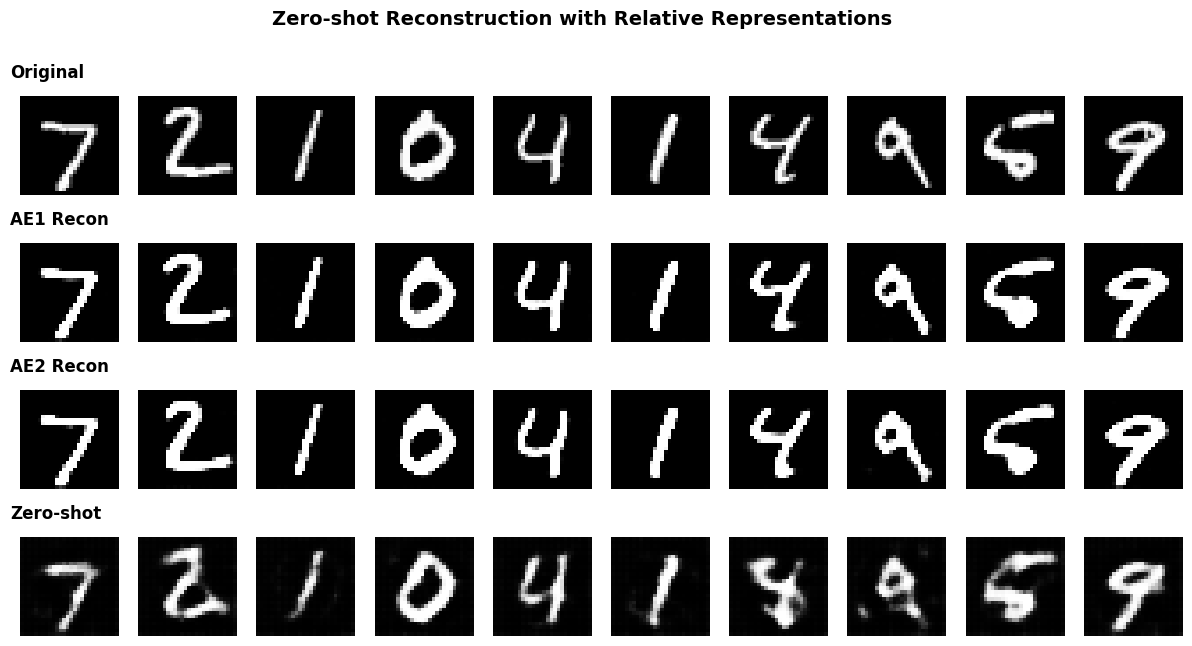

In [37]:
## Getting the reconstructions and plotting ##

# Visualize reconstructions
num_samples = 10

# Get a batch of test images
test_images, test_labels = next(iter(test_loader))
test_images = test_images[:num_samples].to(device)
test_labels = test_labels[:num_samples]

# Unnormalize for visualization
test_images_unnorm = test_images * 0.3081 + 0.1307

# Get direct reconstructions from both autoencoders
# Don't mind the .cpu() and FLoatTensor stuff. It's just to make sure that it works with numpy and plt
with torch.no_grad():
    recon_model1 = model1(test_images).cpu()
    recon_model2 = model2(test_images).cpu()
    
    # Get embeddings from model2
    emb_model2 = model2.encode(test_images).cpu().numpy()
    
    # Compute relreps for these embeddings using our function
    relrep_embeddings = compute_relative_representations(emb_model2, anchors2)
    relrep_embeddings = torch.FloatTensor(relrep_embeddings).to(device)
    
    # Zero-shot reconstruction
    recon_zeroshot = rel_decoder(relrep_embeddings).cpu() #TODO: What are we putting into the relative decoder??

# Use utility function to plot
plot_reconstructions(
    images_list=[test_images_unnorm.cpu(), recon_model1, recon_model2, recon_zeroshot],
    row_labels=['Original', 'AE1 Recon', 'AE2 Recon', 'Zero-shot'],
    num_samples=num_samples,
    suptitle='Zero-shot Reconstruction with Relative Representations',
    save_path='reconstruction_comparison.png'
)
plt.show()

In [43]:
with torch.no_grad():
    # Flatten images to vectors
    original_flat   = test_images_unnorm.cpu().numpy().reshape(num_samples, -1)
    zeroshot_flat   = recon_zeroshot.numpy().reshape(num_samples, -1)

    # Pairwise cosine similarity per image
    orig_norm     = original_flat / (np.linalg.norm(original_flat, axis=1, keepdims=True) + 1e-8)
    zeroshot_norm = zeroshot_flat / (np.linalg.norm(zeroshot_flat, axis=1, keepdims=True) + 1e-8)
    cos_sims      = np.sum(orig_norm * zeroshot_norm, axis=1)

    print(f"Cosine similarity (original vs zero-shot):")
    print(f"  Mean: {cos_sims.mean():.4f}")
    print(f"  Std:  {cos_sims.std():.4f}")
    print(f"  Min:  {cos_sims.min():.4f}")
    print(f"  Max:  {cos_sims.max():.4f}")

Cosine similarity (original vs zero-shot):
  Mean: 0.8652
  Std:  0.0623
  Min:  0.7526
  Max:  0.9583
